# `specscout`: Exploring Transient Events in ALBATROS Direct Spectra

It is designed around a key simple idea: most of the time, the sky is "quiet". Rare deviations from this quiet backgrou: — such as solar flares, meteors, RFI, or instrumental anomalies — can be identified : statistical outliers. This notebook demonstrates the full specscout workflow:

1. Loading and inspecting dynamic spectra
2. Applying preprocessing (e.g. Stokes I, dB scaling)
3. Constructing frame based pipelines
4. Constructing a quiet background model using PCA
5. Detecting transient events via residual scoring
6. Visualizing detected regions of interest (ROIs)

In [1]:
from datetime import timedelta

import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.notebook import tqdm

from specscout.dataset import SpecscoutDataset
from specscout.outlier import QuietSelector, RollingPCABackground
from specscout.preprocess import PreprocessPipeline, step_safe_db, step_stokes_i, step_stokes_iquv
from specscout.roi import find_rois_from_scores, rois_to_dataframe
from specscout.rolling import RollingPCARunner, padded_utc_range
from specscout.viz.interactive import scrub_frames_sequence
from specscout.viz.static import (
    plot_frame,
    plot_roi_event,
    plot_scores_with_rois,
    plot_time_range,
    plot_time_range_instrumental_quicklook,
    plot_time_range_stokes_fractional,
)

plt.rcParams.update({"font.family": "serif"})

## 1. Load and visualize data

We assume data has already been ingested raw direct spectra files into a Zarr store using the cli tool `specscout ingest`. This produces a cube of shape: `(time, frequency, channel)`, where channels correspond to:

- pol00
- pol11
- pol01_mag
- pol01_phase

### 1.1 Explore a region of interest

In [2]:
# Replace with your dataset path
zarr_path = "../data/zarr/MARS2_20240801_20240901.zarr"

# Time span of region of interest
start_utc = "20240801_013000"
stop_utc = "20240801_020000"

#### Plot one raw channel, or all available channels

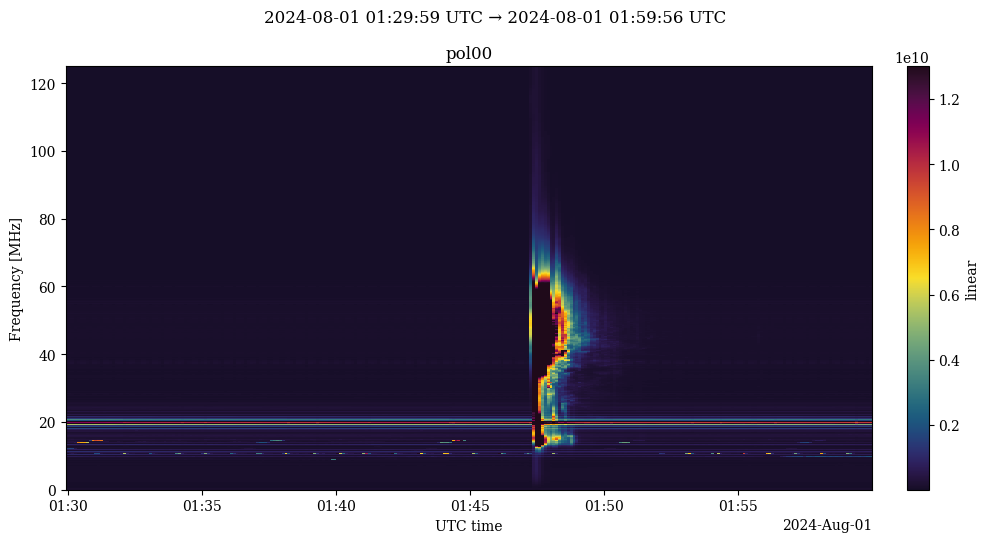

In [3]:
%matplotlib inline
plot_time_range(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    chans=0,
)
plt.tight_layout()
plt.show()

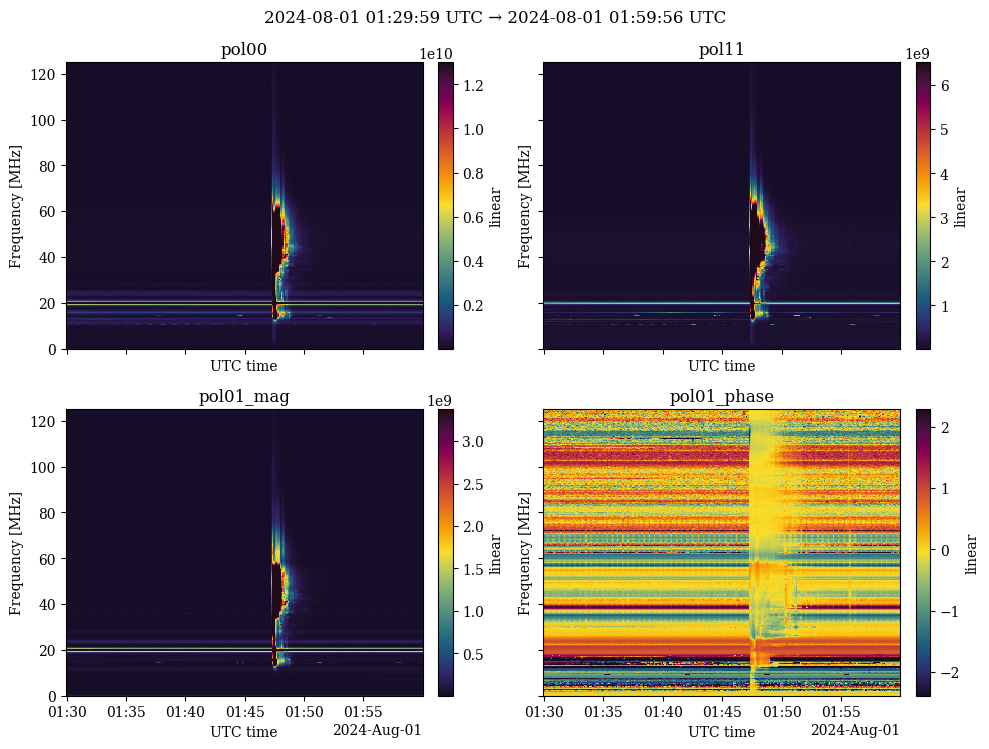

In [4]:
%matplotlib inline
plot_time_range(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    chans=(0, 1, 2, 3),
)
plt.tight_layout()
plt.show()

## 2. Preprocessing

It's often not intuitive to work in linear power space, give the massive dynamic range of the data. We often convert to dB, or even combine intrumental polarisations into stokes parameters. In `specscout` this is achived by building pipelines

### 2.1 dB transform

In [5]:
pipe_db = PreprocessPipeline().add(step_safe_db())

print(pipe_db.summary())

########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:None

n_steps: 1
[0] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}


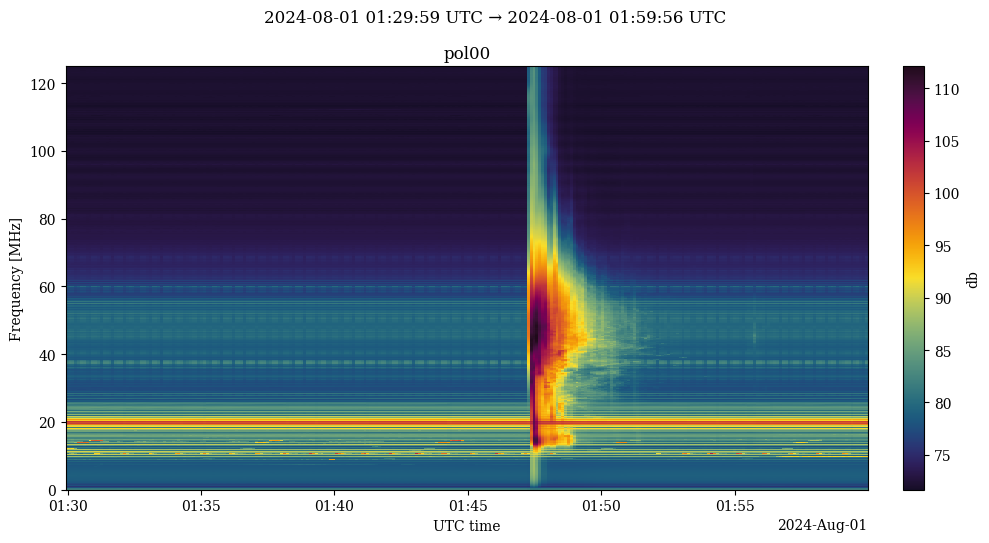

In [6]:
%matplotlib inline
plot_time_range(zarr_path, start_utc=start_utc, stop_utc=stop_utc, chans=0, pipe=pipe_db, clim_percentiles=[0, 100])
plt.tight_layout()
plt.show()

/Users/achokshi/Repos/albatros/specscout/src/specscout/patches.py:487: RuntimeWarning: safe_db is being applied to non power-like channels ('pol01_phase',); this is usually not physically meaningful.
  arr = pipe(arr, meta)


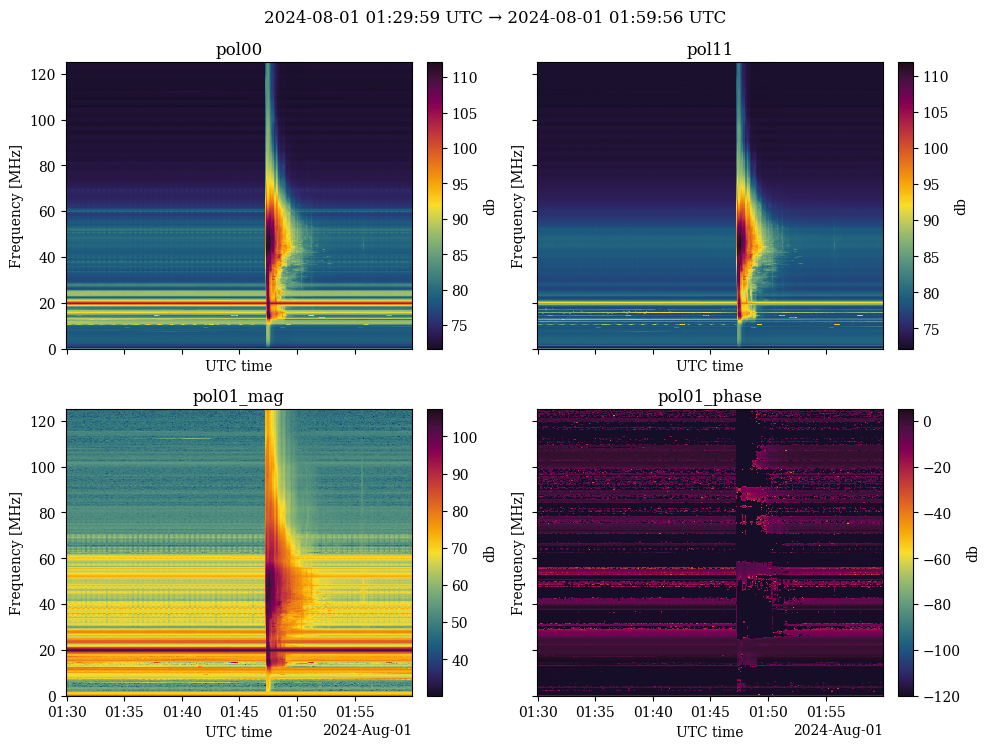

In [7]:
%matplotlib inline
plot_time_range(zarr_path, start_utc=start_utc, stop_utc=stop_utc, chans=(0, 1, 2, 3), pipe=pipe_db, clim_percentiles=[0, 100])
plt.tight_layout()
plt.show()

### 2.2 Instrumental pols quicklook

When looking at instrumental pols (pol00, pol11, pol01_mag, pol01_phase), visualising the data in either fully linear of logrithimic units is not physically meaningful. pol00, pol11, pol01_mag are best seen in dB, while pol01_phase is best represented in linear units as it is an angle. The plot below fixes this.

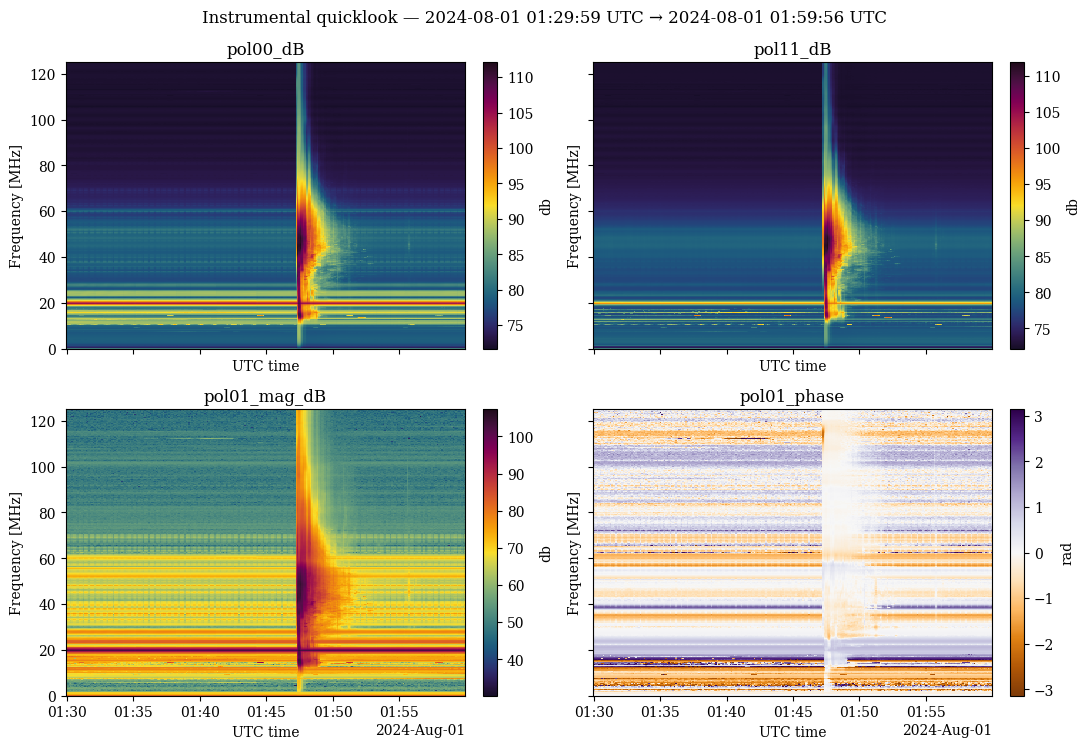

In [8]:
%matplotlib inline

pipe = PreprocessPipeline()

plot_time_range_instrumental_quicklook(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    chans=(0, 1, 2, 3),
    pipe=pipe,
    clim_percentiles=[0, 100],
)
plt.tight_layout()
plt.show()

### 2.3 Stokes dB

Note that we must provide channels (0,1)->(pol00, pol11) to the plotting functions, as stokes_I is constructed from the two linear pols

In [9]:
pipe_stokes_i_db = PreprocessPipeline().add(step_stokes_i()).add(step_safe_db())

print(pipe_stokes_i_db.summary())

########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:('stokes_I',)

n_steps: 2
[0] stokes_i in_space=linear out_space=linear in_channels=['pol00', 'pol11'] out_channels=['stokes_I'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11'], 'channel_order_out': ['stokes_I'], 'convention': 'stokes_I = 0.5 * (pol00 + pol11)'}
[1] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}


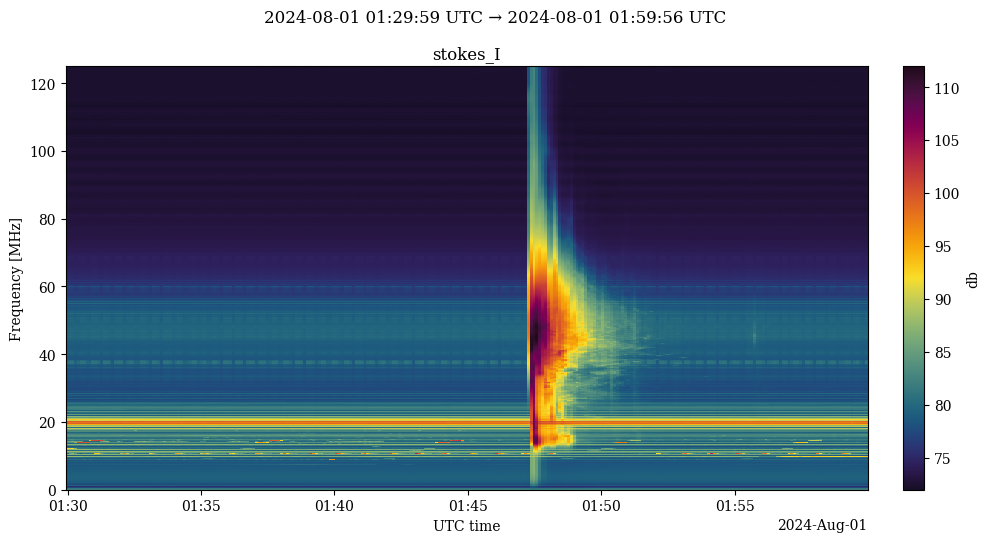

In [10]:
%matplotlib inline
plot_time_range(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    clim_percentiles=[0, 100],
)
plt.tight_layout()
plt.show()

### 2.4 Full Stokes

In [11]:
pipe_stokes_iquv_db = PreprocessPipeline().add(step_stokes_iquv()).add(step_safe_db())

print(pipe_stokes_iquv_db.summary())

########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:('stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V')

n_steps: 2
[0] stokes_iquv in_space=linear out_space=linear in_channels=['pol00', 'pol11', 'pol01_mag', 'pol01_phase'] out_channels=['stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11', 'pol01_mag', 'pol01_phase'], 'channel_order_out': ['stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V'], 'convention': {'stokes_I': '0.5 * (pol00 + pol11)', 'stokes_Q': '0.5 * (pol00 - pol11)', 'stokes_U': 'real(pol01_mag * exp(1j * pol01_phase))', 'stokes_V': 'imag(pol01_mag * exp(1j * pol01_phase))'}}
[1] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}


/Users/achokshi/Repos/albatros/specscout/src/specscout/patches.py:487: RuntimeWarning: safe_db is being applied to non power-like channels ('stokes_Q', 'stokes_U', 'stokes_V'); this is usually not physically meaningful.
  arr = pipe(arr, meta)


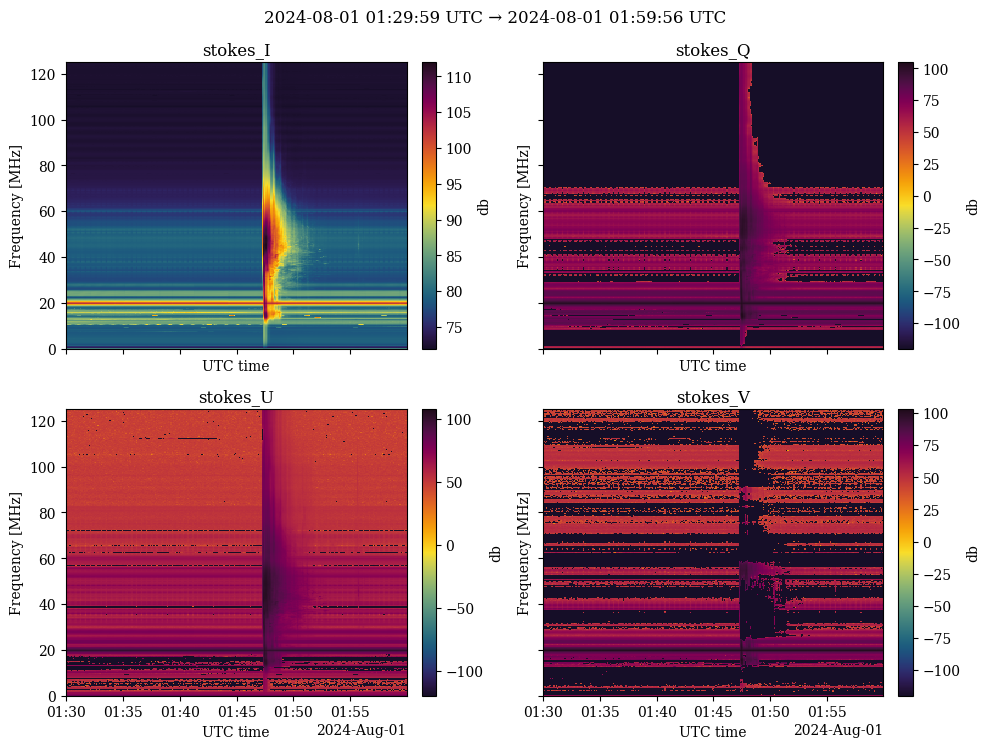

In [12]:
plot_time_range(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    chans=(0, 1, 2, 3),
    pipe=pipe_stokes_iquv_db,
    clim_percentiles=[0, 100],
)
plt.tight_layout()
plt.show()

### 2.5 Stokes pols quicklook

When looking at stokes pols (I,Q,U,V), visualising the data in either fully linear of logrithimic units is not physically meaningful. Stokes I is best seen in dB, while Q,U,V are best represented in normalised linear units. The plot below fixes this.

########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   linear
input_channels: None
output_channels:('stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V')

n_steps: 1
[0] stokes_iquv in_space=linear out_space=linear in_channels=['pol00', 'pol11', 'pol01_mag', 'pol01_phase'] out_channels=['stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11', 'pol01_mag', 'pol01_phase'], 'channel_order_out': ['stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V'], 'convention': {'stokes_I': '0.5 * (pol00 + pol11)', 'stokes_Q': '0.5 * (pol00 - pol11)', 'stokes_U': 'real(pol01_mag * exp(1j * pol01_phase))', 'stokes_V': 'imag(pol01_mag * exp(1j * pol01_phase))'}}


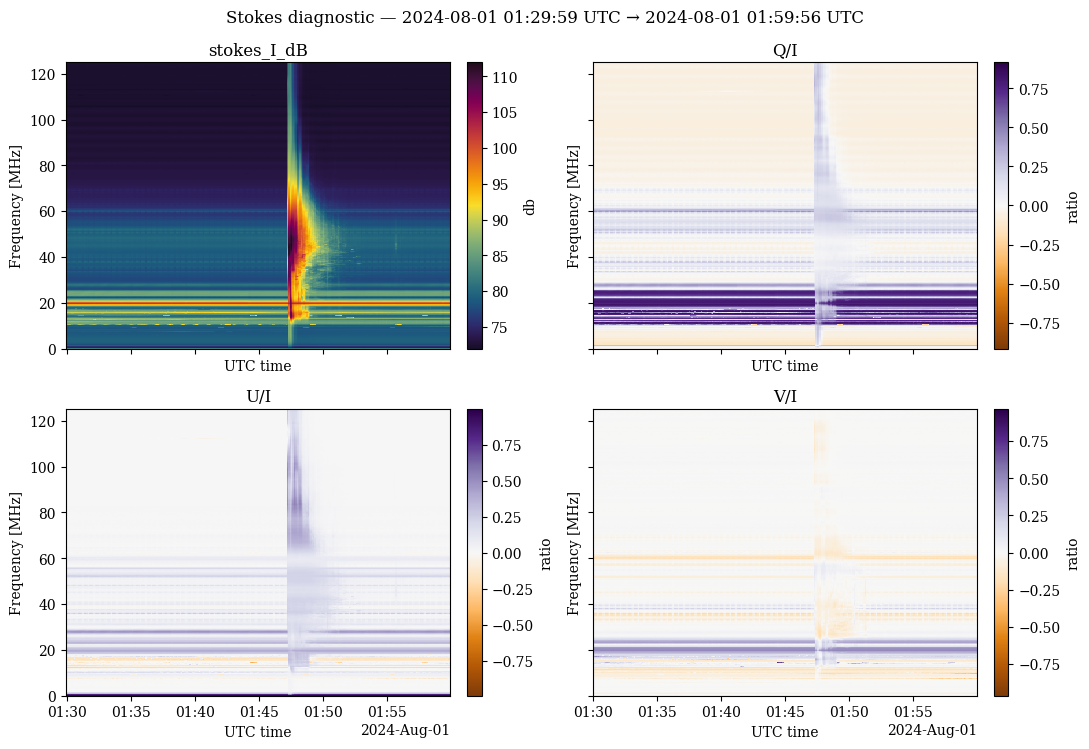

In [13]:
%matplotlib inline

pipe_stokes_iquv = PreprocessPipeline().add(step_stokes_iquv())

print(pipe_stokes_iquv.summary())

plot_time_range_stokes_fractional(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    chans=(0, 1, 2, 3),
    pipe=pipe_stokes_iquv,
    clim_percentiles=[0, 100],
)
plt.tight_layout()
plt.show()

## 3. Frame-based pipelines with `SpecscoutDataset`

So far, we have visualised arbitrary contiguous time ranges directly from the
underlying Zarr store. This is extremely useful for inspecting known events or
building intuition for the data.

However, most of `specscout` is built around a different abstraction:
**rolling time–frequency frames**.

A `SpecscoutDataset` turns a Zarr cube into a lazy sequence of overlapping
windows, each with a fixed duration and cadence step. Each item in the dataset
contains:

- a time–frequency frame of shape `(T, F)` or `(T, F, C)`
- a corresponding `FrameMeta` object describing where that frame came from

This frame-based view is useful because it matches how downstream transient
search is performed:

- preprocessing is applied frame-by-frame
- PCA background models are fit on collections of frames
- outlier scores are assigned to individual frames
- interesting events can then be inspected interactively

In other words, `plot_time_range(...)` is ideal when you already know the time
interval you want to examine, while `SpecscoutDataset` is ideal when you want
to scan, sample, score, and scrub through the data in a uniform way.


Below we construct a dataset of overlapping 20-minute windows, stepped every
5 minutes. Since we passed `chans=(0, 1)` together with a preprocessing
pipeline that converts `(pol00, pol11) -> Stokes I -> dB`, each dataset item
is a single 2D waterfall frame in Stokes I dB. This is the same science product
we plotted earlier with `plot_time_range(...)`, but now represented as a sequence
of fixed-size rolling windows.

In [14]:
# Time span of region of interest
start_utc = "20240801_000000"
stop_utc = "20240802_000000"

# A window is a chunk of time we look at individually
# We iterate over multiple windows. Below we define
# 20 minute windows
window_seconds = 20 * 60

# Often, when looking for transients, we don't want to
# look at fully adjecent windows. Rather we increment
# by a fraction of the window to form partially
# overlapping windows. Here adjacent windows as
# 5 minutes apart
step_seconds = 5 * 60

# SpecscoutDataset support pipeline objects
pipe_stokes_i_db = PreprocessPipeline().add(step_stokes_i()).add(step_safe_db())

ds = SpecscoutDataset(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    window_seconds=window_seconds,
    step_seconds=step_seconds,
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    return_meta=True,
)

print(f"Number of frames: {len(ds)}")
print(ds.plan)

Number of frames: 282
DatasetPlan(frame_plan=FramePlan(i_start=0, i_stop=13411, window_n=186, step_n=47, n_frames=282, dt_s=6.442450944000001, t0_unix_s=1722470400.0), f_start=0, f_stop=2048, chans=(0, 1))


### 3.1 Inspecting one frame directly

In [15]:
x0, meta0 = ds[0]

print("Frame shape:", x0.shape)
print(meta0)

Frame shape: (186, 2048)
FrameMeta(t_start_idx=0, t_end_idx=186, frame_idx=0, start_time_utc=datetime.datetime(2024, 8, 1, 0, 0, tzinfo=datetime.timezone.utc), dt_s=6.442450944000001)


In [16]:
print(ds.pipe.summary())

########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:('stokes_I',)

n_steps: 2
[0] stokes_i in_space=linear out_space=linear in_channels=['pol00', 'pol11'] out_channels=['stokes_I'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11'], 'channel_order_out': ['stokes_I'], 'convention': 'stokes_I = 0.5 * (pol00 + pol11)'}
[1] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}


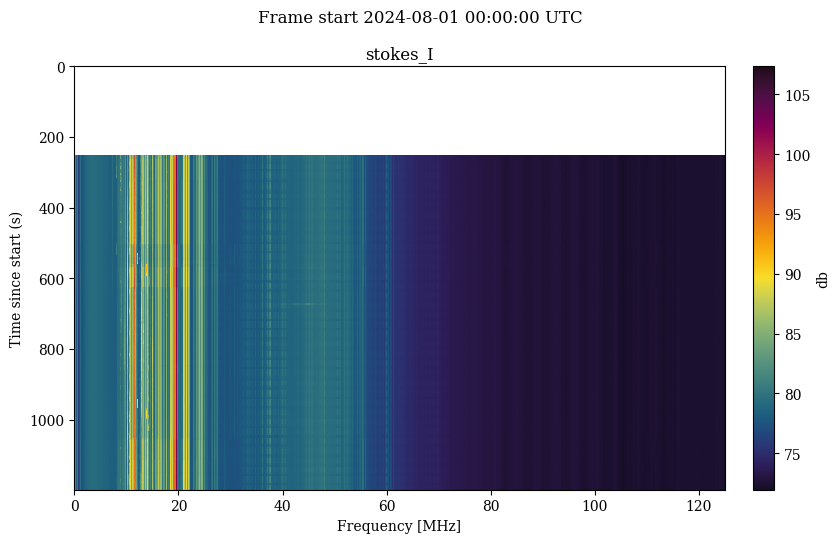

In [17]:
%matplotlib inline
plot_frame(
    ds,
    idx=0,
    clim_percentiles=(0, 100),
)
plt.tight_layout()
plt.show()

#### Another index

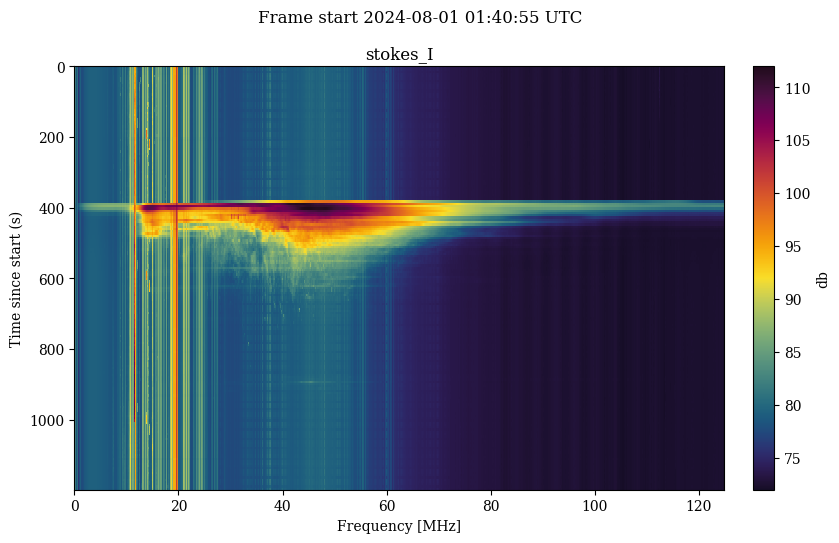

In [18]:
%matplotlib inline
plot_frame(
    ds,
    idx=20,
    clim_percentiles=(0, 100),
)
plt.tight_layout()
plt.show()

This is the frame-based analogue of `plot_time_range(...)`.
The key difference is that `plot_time_range(...)` reads one continuous interval
directly from disk, while `plot_frame(...)` visualises a single rolling window
from a `SpecscoutDataset`. This is the representation used internally by the
outlier-search machinery.

### 3.2 Interactive scrubber

A particularly convenient way to explore a frame-based dataset is to scrub
through it interactively. This is especially useful in notebooks when you want
to inspect how a transient evolves from one rolling window to the next.

In [19]:
scrubber = scrub_frames_sequence(
    ds,
    start_idx=0,
    stop_idx=None,
    clim_percentiles=(0, 100),
)

display(scrubber.container)

#### Instumental pols dB scrubber

In [20]:
ds_instr = SpecscoutDataset(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    window_seconds=20 * 60,
    step_seconds=5 * 60,
    chans=(0, 1, 2, 3),
    pipe=PreprocessPipeline().add(step_safe_db()),
    return_meta=True,
)

scrubber = scrub_frames_sequence(
    ds_instr,
    start_idx=0,
    stop_idx=None,
    clim_percentiles=(0, 100),
)

display(scrubber.container)

#### Stokes linear scrubber

In [21]:
ds_instr = SpecscoutDataset(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    window_seconds=20 * 60,
    step_seconds=5 * 60,
    chans=(0, 1, 2, 3),
    pipe=PreprocessPipeline().add(step_stokes_iquv()),
    return_meta=True,
)

scrubber = scrub_frames_sequence(
    ds_instr,
    start_idx=0,
    stop_idx=None,
    clim_percentiles=(0, 100),
)

display(scrubber.container)

## 4. Quiet backgrounds and PCA residuals

Now that we can represent the data as a sequence of rolling time–frequency
frames, we can build a simple but powerful transient-detection model. The
central assumption behind `specscout` is: most frames are dominated by a 
relatively stable “background”, while transient events appear as deviations
away from that background. We therefore proceed in two steps:

1. *Select a subset of "quiet" frames* that appear least contaminated by
   bright transient structure.
3. *Fit a low-rank PCA model* to those quiet frames, and use that model to
   construct a tailored background estimate for any frame of interest.

A transient is then detected not from the raw data itself, but from the *residual*:

$$
R = X - \hat{X}
$$

where $X$ is the observed frame and $\hat{X}$ is the PCA background
reconstruction. This is a useful strategy because the PCA model captures
persistent or slowly varying structure — such as bandpass shape, stable sky
structure, and other common patterns — while transient features tend to remain
in the residual.

### 4.1 Representing frames as vectors

Suppose one frame has shape $(T, F)$, where:

- $T$ = number of time samples in the frame
- $F$ = number of frequency channels

For statistical modelling, we flatten each frame into a single feature vector
of length

$$
D = T \times F.
$$

If we collect $N$ frames, we can assemble them into a matrix

$$
X \in \mathbb{R}^{N \times D},
$$

where each row corresponds to one flattened frame. This is the canonical 
representation used internally by the outlier machinery:

- rows = frames
- columns = time–frequency pixels

If a frequency mask is used, masked channels are excluded before flattening, so
the effective feature dimension $D$ is reduced.

### 4.2 Quiet frame selection with `QuietSelector`

Before fitting PCA, we would like to avoid training on frames that already
contain strong transients. `QuietSelector` provides a simple method for this.
Given a batch of frames, it computes a scalar **quietness score** for each
frame. Lower scores correspond to “quieter” frames. The quietest fraction of
frames is then selected and used to train the PCA background model.

#### How quietness is computed

After masking and flattening each frame into a row vector $x_i$, we compute a
summary statistic such as:

- a high percentile, e.g. $p_{99}(x_i)$
- a norm such as $\|x_i\|_1$ or $\|x_i\|_2$
- a tail statistic such as the sum of the largest $k$ pixels

For example, with the `p99` method, the quietness score is $s_i = \mathrm{percentile}_{99}(x_i).$
Frames with unusually bright structure tend to have larger upper-tail values,
so sorting by $s_i$ and taking the smallest fraction often gives a good set
of background-dominated examples. This is intentionally simple: the selector
is not trying to classify events in detail. It is only trying to answer:
*which frames look least contaminated?*

### 4.3 PCA background modelling with `RollingPCABackground`

Once we have selected quiet frames, we fit a PCA model to them. 
Suppose the quiet-frame matrix is

$$
X_{\mathrm{quiet}} \in \mathbb{R}^{N_q \times D}.
$$

If centering is enabled, we first subtract the mean feature vector:

$$
\mu = \frac{1}{N_q} \sum_{i=1}^{N_q} x_i,
\qquad
X_c = X_{\mathrm{quiet}} - \mu.
$$

We then compute a truncated singular value decomposition (SVD):

$$
X_c \approx U_k S_k V_k^\top,
$$

where:

- $U_k \in \mathbb{R}^{N_q \times k}$
- $S_k \in \mathbb{R}^{k \times k}$
- $V_k^\top \in \mathbb{R}^{k \times D}$

The rows of $V_k^\top$ form an orthonormal basis for a $k$-dimensional
subspace capturing the dominant structure in the quiet frames.

#### Interpreting the PCA basis

Each basis vector is a pattern in flattened time–frequency space. In practice,
the PCA model learns combinations of structures such as:

- broad bandpass shape
- persistent spectral features
- common time–frequency morphology shared across quiet frames

A new observed frame $x$ is then projected into this subspace.

### 4.4 Tailored background reconstruction

Given a new flattened frame $x \in \mathbb{R}^{D}$, and letting
$V_k \in \mathbb{R}^{k \times D}$ denote the PCA basis, we form the
mean-subtracted vector

$$
x_c = x - \mu.
$$

We then project onto the PCA basis:

$$
c = x_c V_k^\top,
$$

where $c \in \mathbb{R}^{k}$ are the PCA coefficients.

The low-rank reconstruction is then

$$
\hat{x}_c = c V_k,
\qquad
\hat{x} = \hat{x}_c + \mu.
$$

This reconstruction is *tailored to the individual frame*: although the PCA
basis is learned from many quiet frames, each new frame gets its own set of
projection coefficients $c$, and hence its own best-fitting low-rank
background estimate.

This is an important point: PCA is not producing one fixed background image
for the whole dataset. It is producing a low-dimensional basis from which a
different background can be reconstructed for each frame.

### 4.4 Residuals and outlier scoring

The residual is defined as

$$
r = x - \hat{x}.
$$

If the PCA model captures the stable background well, then:

- background-dominated frames should have relatively small residuals
- frames containing transients should leave behind localized residual structure

In many use cases we care primarily about *positive residuals*, i.e. features
that are brighter than the background model. In that case we clip:

$$
r^+ = \max(r, 0).
$$

An outlier score is then computed from the residual using the same style of
metrics as before:

- percentile of the residual
- sum of top-$k$ residual pixels
- $L^1$, $L^2$, or $L^p$ norms
- thresholded excess mass

For example, a top-$k$ score is

$$
s_{\mathrm{outlier}}(r) = \sum_{j \in \mathrm{largest}\ k} r_j^+.
$$

Large scores indicate frames whose residuals contain unusually bright
time–frequency structure.

In [22]:
start_utc = "20240801_000000"
stop_utc = "20240802_000000"
window_seconds = 20 * 60
step_seconds = 5 * 60

pipe_stokes_i_db = PreprocessPipeline().add(step_stokes_i()).add(step_safe_db())

ds = SpecscoutDataset(
    zarr_path,
    start_utc=start_utc,
    stop_utc=stop_utc,
    window_seconds=window_seconds,
    step_seconds=step_seconds,
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    return_meta=True,
)

batch_indices = np.arange(0, len(ds))   # load all frames

frames, metas = ds.to_numpy_batch(
    batch_indices,
    return_meta=True,
)

print("Batch shape:", frames.shape)
print("Number of metas:", len(metas))

Batch shape: (282, 186, 2048)
Number of metas: 282


For this demonstration, we work with a batch of frames already transformed into
Stokes I dB. We now ask: which of these frames look quiet enough to use for
background training?

In [23]:
example_x, example_meta = ds[0]
T, F = example_x.shape
rfi_mask = np.ones((F,), dtype=bool)
rfi_mask[116:384] = False

In [24]:
qs = QuietSelector(
    method="p99",
    quiet_fraction=0.3,
    min_finite_frac=0.7,
    freq_mask=rfi_mask,
)

quiet_scores = qs.scores(frames)
quiet_idx = qs.select_quiet(frames)

print("quiet_scores shape:", quiet_scores.shape)
print("Number of selected quiet frames:", len(quiet_idx))
print("First 10 quiet indices:", quiet_idx[:10])

quiet_scores shape: (282,)
Number of selected quiet frames: 84
First 10 quiet indices: [146 256 255 147 257 242 241 243 136 254]


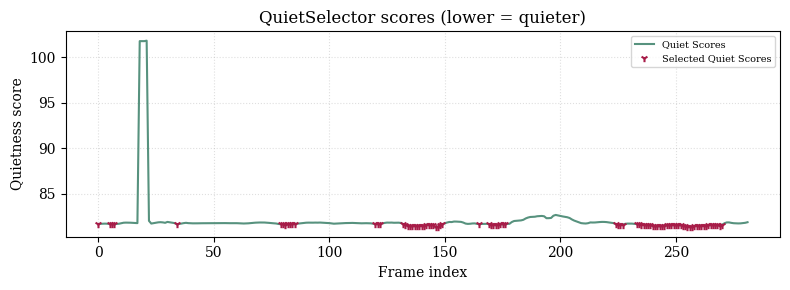

In [25]:
%matplotlib inline

plt.figure(figsize=(8, 3))
plt.plot(batch_indices, quiet_scores, color=cmr.pride(0.3), label="Quiet Scores")
plt.scatter(batch_indices[quiet_idx], quiet_scores[quiet_idx], marker="1", s=28, color=cmr.pride(0.8), zorder=7, label="Selected Quiet Scores")
plt.xlabel("Frame index")
plt.ylabel("Quietness score")
plt.title("QuietSelector scores (lower = quieter)")
plt.grid(ls=":", alpha=0.4)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

The exact meaning of the quietness score depends on the chosen metric. Here we
used `p99`, so each frame is summarised by its 99th percentile pixel value.
Frames with large bright structures tend to have larger upper tails and are
therefore ranked as less quiet. The selected quiet frames are not guaranteed
to be perfectly event-free; the goal is simply to assemble a subset that is as
background-dominated as possible.

In [26]:
bg = RollingPCABackground(
    k=256,
    center=True,
    # freq_mask=rfi_mask
)

bg.fit(frames[quiet_idx])

print("PCA fit complete")
print("Vt_ shape:", bg.Vt_.shape)
print("S_ shape:", bg.S_.shape)

PCA fit complete
Vt_ shape: (59, 380928)
S_ shape: (59,)


After fitting:

- `mu_` is the mean quiet-frame vector
- `Vt_` contains the learned PCA basis vectors
- `S_` contains the singular values, which indicate how much variance is
  captured by each PCA mode

The number of modes \(k\) controls model complexity:

- too small: the model underfits and leaves too much background in the residual
- too large: the model may begin to absorb transient structure

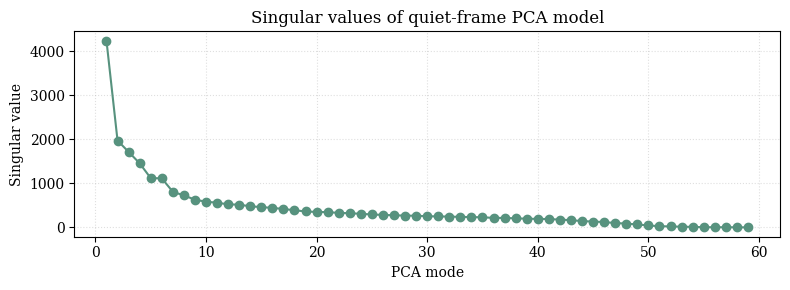

In [27]:
%matplotlib inline

plt.figure(figsize=(8, 3))
plt.plot(np.arange(1, len(bg.S_) + 1), bg.S_, marker="o", color=cmr.pride(0.3))
plt.xlabel("PCA mode")
plt.ylabel("Singular value")
plt.title("Singular values of quiet-frame PCA model")
plt.grid(ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

In [28]:
example_idx = 19

x = frames[example_idx:example_idx + 1]
x_hat = bg.reconstruct(x, k=16)
resid = bg.residuals(x, k=16)

x2 = x[0].reshape(frames.shape[1], frames.shape[2])
xhat2 = x_hat[0].reshape(frames.shape[1], frames.shape[2])
resid2 = resid[0].reshape(frames.shape[1], frames.shape[2])

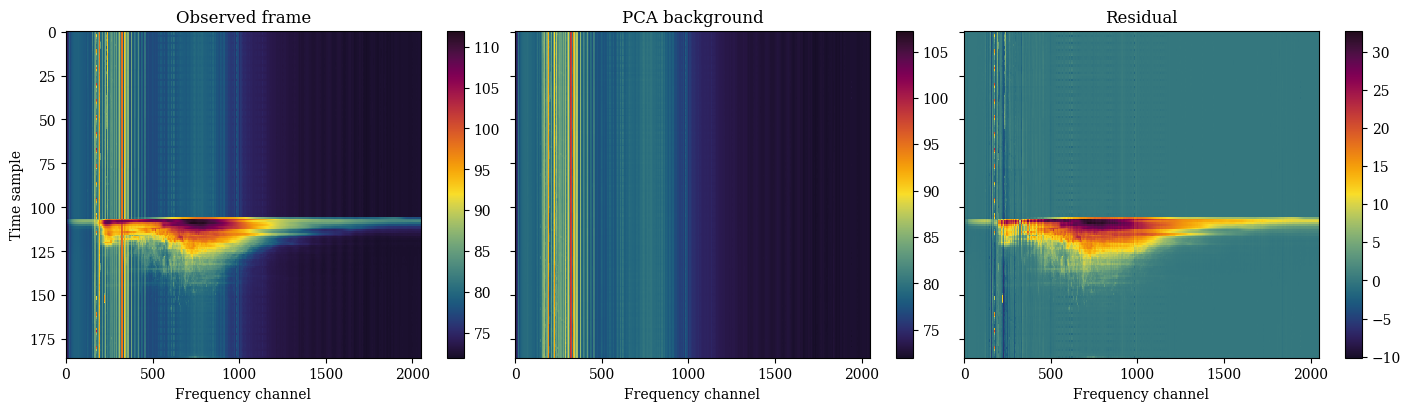

In [29]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True, sharey=True)

im0 = axs[0].imshow(x2, aspect="auto", interpolation="none", cmap=cmr.pride)
axs[0].set_title("Observed frame")
axs[0].set_xlabel("Frequency channel")
axs[0].set_ylabel("Time sample")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(xhat2, aspect="auto", interpolation="none", cmap=cmr.pride)
axs[1].set_title("PCA background")
axs[1].set_xlabel("Frequency channel")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(resid2, aspect="auto", interpolation="none", cmap=cmr.pride)
axs[2].set_title("Residual")
axs[2].set_xlabel("Frequency channel")
fig.colorbar(im2, ax=axs[2])

plt.show()

This plot is the key conceptual result:

- the *observed frame* contains both background and any transient structure
- the *PCA background* captures the dominant low-rank morphology
- the *residual* highlights what is not well explained by the quiet-frame model

A good background model suppresses common structure while leaving unusual
features behind.

In [30]:
scores = bg.score(
    frames,
    method="p99",
    k_pca=16,
)

rank_idx = np.argsort(scores)[::-1]

print("Top 10 outlier indices:", rank_idx[:10])
print("Top 10 scores:", scores[rank_idx[:10]])

Top 10 outlier indices: [ 21  18  20  19 281 280 279 276 275 274]
Top 10 scores: [22.31193352 22.22848129 22.22146606 22.20446205  3.92548084  3.64759922
  3.41281939  3.3209374   3.32081127  3.24870586]


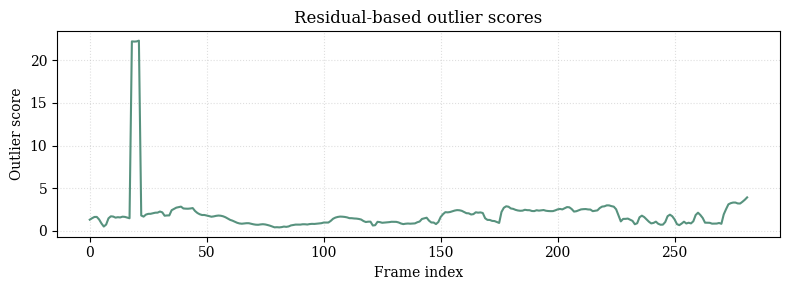

In [31]:
%matplotlib inline

plt.figure(figsize=(8, 3))
plt.plot(batch_indices, scores, color=cmr.pride(0.3))
plt.xlabel("Frame index")
plt.ylabel("Outlier score")
plt.title("Residual-based outlier scores")
plt.grid(ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

In the example above, we fit one PCA model to a fixed batch of frames. In the
full rolling search, `RollingPCABackground` is repeatedly refit on a moving
context window, so that the background model can adapt to slow changes in the
data over time.

The key ideas remain the same:

1. choose quiet frames
2. learn a low-rank basis
3. reconstruct each frame in that basis
4. score the residual

## 5. Rolling PCA and Region-of-Interest (ROI) detection

In the previous section, we fit a PCA background model to a fixed batch of
frames. This is useful for understanding the method, but not sufficient for
real datasets, where the background evolves over time.

To address this, we move to a **rolling analysis**:

- for each target frame, we construct a *local context window*
- we select quiet frames within that window
- we fit a PCA model to those quiet frames
- we compute a residual and score for the target frame

This produces a time series of outlier scores, which can be used to identify
regions of interest (ROIs).

For a target frame at index $t$, we define a context window:

$$
\mathcal{W}_t = \{t - w, \dots, t + w\}
$$

From this window, we select a subset of quiet frames:

$$
\mathcal{Q}_t \subset \mathcal{W}_t
$$

We then fit a PCA model using only $\mathcal{Q}_t$, and compute a residual
score for frame $t$.

### 5.1 The rolling PCA pipeline

`specscout` implements this logic in a rolling pipeline that:

1. iterates over frames in the dataset
2. constructs a context window for each frame
3. selects quiet frames using `QuietSelector`
4. fits a PCA model using `RollingPCABackground`
5. computes a residual-based outlier score

The result is a time series of scores aligned with the dataset frames.

In [32]:
zarr_path = "../data/zarr/MARS2_20240801_20240901.zarr"

analysis_start_utc = "20240801_000000"
analysis_stop_utc = "20240808_000000"

chan = (0, 1)

context_hours = 24
stride_hours = 1
score_hours = 1
gap_hours = 0

quiet_fraction = 0.3

k_fit = 128  # modes to fit
k_pca = 16  # modes used for reconstruct in scoring

score_kwargs = dict(method="p99", min_finite_frac=0.7)

ds_start_utc, ds_stop_utc = padded_utc_range(
    analysis_start_utc=analysis_start_utc,
    analysis_stop_utc=analysis_stop_utc,
    context_hours=context_hours,
)

pipe_stokes_i_db = (
    PreprocessPipeline(input_space="linear")
    .with_metadata(
        zarr_path=zarr_path,
        notes="Stokes I from chan 0/1, then safe_db",
    )
    .add(step_stokes_i(name="stokes_i"))
    .add(step_safe_db(name="safe_db"))
)

ds = SpecscoutDataset(
    zarr_path,
    start_utc=ds_start_utc,
    stop_utc=ds_stop_utc,
    window_seconds=20 * 60,
    step_seconds=5 * 60,
    chans=chan,
    pipe=pipe_stokes_i_db,
    return_meta=True,
)

print("Dataset padded range:", ds_start_utc, "->", ds_stop_utc)
print("n_frames:", len(ds))
print(pipe_stokes_i_db.summary())

example_x, example_meta = ds[0]
T, F = example_x.shape
rfi_mask = np.ones((F,), dtype=bool)
rfi_mask[116:384] = False

print("Frame shape:", example_x.shape, "mask shape:", rfi_mask.shape)

qs = QuietSelector(
    method="p99",
    quiet_fraction=quiet_fraction,
    freq_mask=rfi_mask,
)

bg = RollingPCABackground(
    k=k_fit,
    center=True,
    freq_mask=rfi_mask,
    use_randomized=True,
    n_iter=2,
    random_state=42,
)

runner = RollingPCARunner(
    ds=ds,
    quiet_selector=qs,
    background=bg,
    context_hours=context_hours,
    stride_hours=stride_hours,
    score_hours=score_hours,
    gap_hours=gap_hours,
    k_pca=k_pca,
    score_kwargs=score_kwargs,
    store_masked=True,
)

Dataset padded range: 20240731_120000 -> 20240808_120000
n_frames: 2137
########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:('stokes_I',)

metadata: {'zarr_path': '../data/zarr/MARS2_20240801_20240901.zarr', 'notes': 'Stokes I from chan 0/1, then safe_db'}
n_steps: 2
[0] stokes_i in_space=linear out_space=linear in_channels=['pol00', 'pol11'] out_channels=['stokes_I'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11'], 'channel_order_out': ['stokes_I'], 'convention': 'stokes_I = 0.5 * (pol00 + pol11)'}
[1] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}
Frame shape: (186, 2048) mask shape: (2048,)


In [33]:
times: list[pd.Timestamp] = []
frame_idx: list[int] = []
scores: list[float] = []

total = runner.n_steps(analysis_start_utc, analysis_stop_utc)

for res in tqdm(
    runner.run(
        analysis_start_utc=analysis_start_utc,
        analysis_stop_utc=analysis_stop_utc,
    ),
    total=total,
    colour="seagreen",
    desc="Rolling PCA",
):
    for score, meta in zip(res.scores, res.metas):
        times.append(pd.Timestamp(meta.start_time_utc))
        frame_idx.append(int(meta.frame_idx))
        scores.append(float(score))

df_scores = (
    pd.DataFrame(
        {
            "time": times,
            "frame_idx": frame_idx,
            "score": scores,
        }
    )
    .sort_values("time")
    .reset_index(drop=True)
)

Rolling PCA:   0%|          | 0/168 [00:00<?, ?it/s]

In [34]:
df_scores.head()

,time,frame_idx,score
0,2024-08-01 00:00:00+00:00,0,0.274691
1,2024-08-01 00:05:02.795194+00:00,1,0.178710
2,2024-08-01 00:10:05.590389+00:00,2,0.174913
3,2024-08-01 00:15:08.385583+00:00,3,0.153078
4,2024-08-01 00:20:11.180778+00:00,4,0.167542


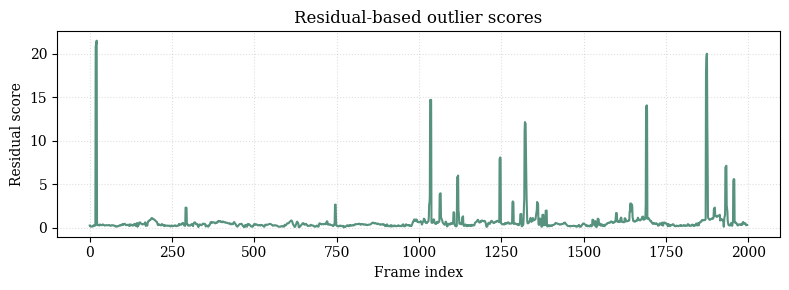

In [35]:
%matplotlib inline

plt.figure(figsize=(8, 3))
plt.plot(df_scores["frame_idx"], df_scores["score"], color=cmr.pride(0.3))
plt.xlabel("Frame index")
plt.ylabel("Residual score")
plt.title("Residual-based outlier scores")
plt.grid(ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

### 5.2 From scores to regions of interest

The rolling pipeline produces a scalar score for each frame. High scores
indicate frames with unusually large residual structure.

To identify candidate events, we apply a threshold:

$$
\text{ROI} = \{ t : s_t > \tau \}
$$

In practice, this threshold can be chosen:

- as a percentile (e.g. top 1%)
- using a fixed value
- or adaptively from the score distribution

In [36]:
threshold, rois = find_rois_from_scores(
    df_scores,
    nsig=3,
    pad=timedelta(minutes=5),
    merge_gap=timedelta(minutes=20),
)
df_rois = rois_to_dataframe(rois)

In [37]:
df_rois

,start,stop,peak_score,sum_score,n_frames
0,2024-08-01 01:25:50.313499+00:00,2024-08-01 01:50:58.699082+00:00,21.487730,84.648748,4
1,2024-08-01 15:43:45.496541+00:00,2024-08-01 15:58:48.291736+00:00,1.130346,2.260354,2
2,2024-08-02 00:23:33.401561+00:00,2024-08-02 00:48:41.787144+00:00,2.336126,9.259824,4
3,2024-08-03 14:34:42.419804+00:00,2024-08-03 14:54:48.010193+00:00,2.677347,7.997788,3
4,2024-08-04 14:32:59.050199+00:00,2024-08-04 15:18:18.616560+00:00,14.697370,68.992236,8
5,2024-08-04 17:19:31.291613+00:00,2024-08-04 17:54:45.267585+00:00,3.971162,17.936802,6
6,2024-08-04 20:51:28.689777+00:00,2024-08-04 21:11:34.280165+00:00,1.789716,5.321226,3
7,2024-08-04 21:46:59.436915+00:00,2024-08-04 22:22:13.412887+00:00,6.010293,27.128531,6
8,2024-08-04 23:02:41.364830+00:00,2024-08-04 23:27:49.750413+00:00,1.326022,5.003000,4
9,2024-08-05 08:38:00.016988+00:00,2024-08-05 09:03:08.402571+00:00,8.090555,31.935265,4


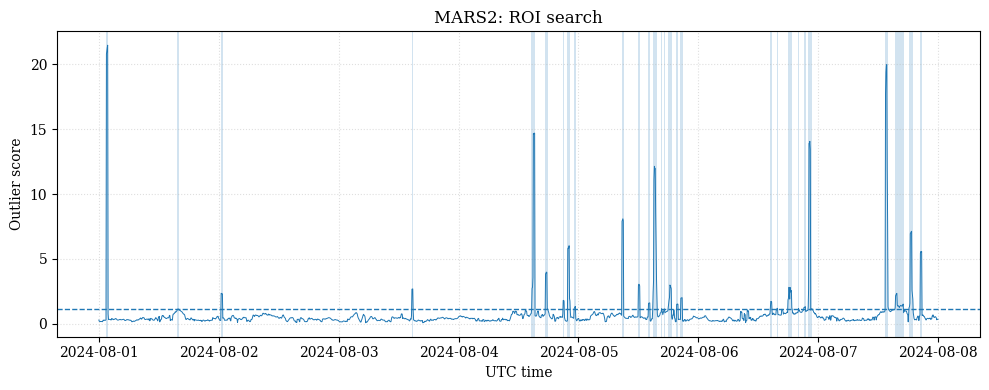

In [38]:
%matplotlib inline

fig, _ax = plot_scores_with_rois(
    df_scores,
    rois,
    threshold=threshold,
    title=("MARS2: ROI search"),
)
plt.tight_layout()
plt.show()

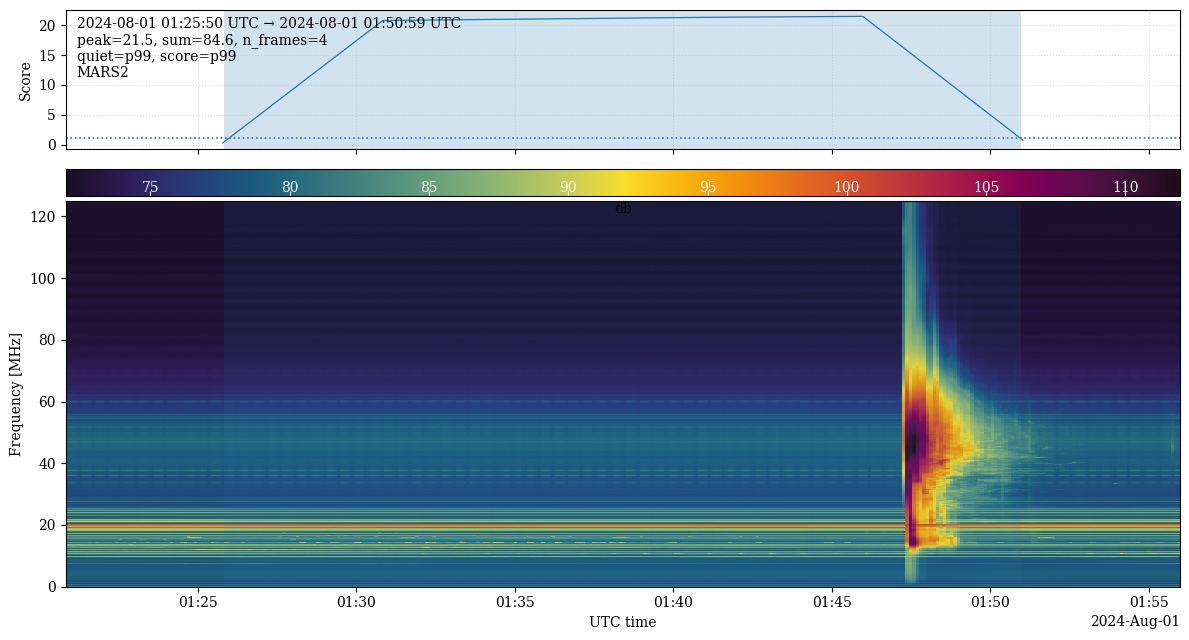

In [39]:
%matplotlib inline

fig, _axs = plot_roi_event(
    station="MARS2",
    roi=rois[0],
    df_scores=df_scores,
    zarr_path=zarr_path,
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    plot_pad_minutes=5,
    threshold=threshold,
    quiet_label="p99",
    score_label="p99",
)